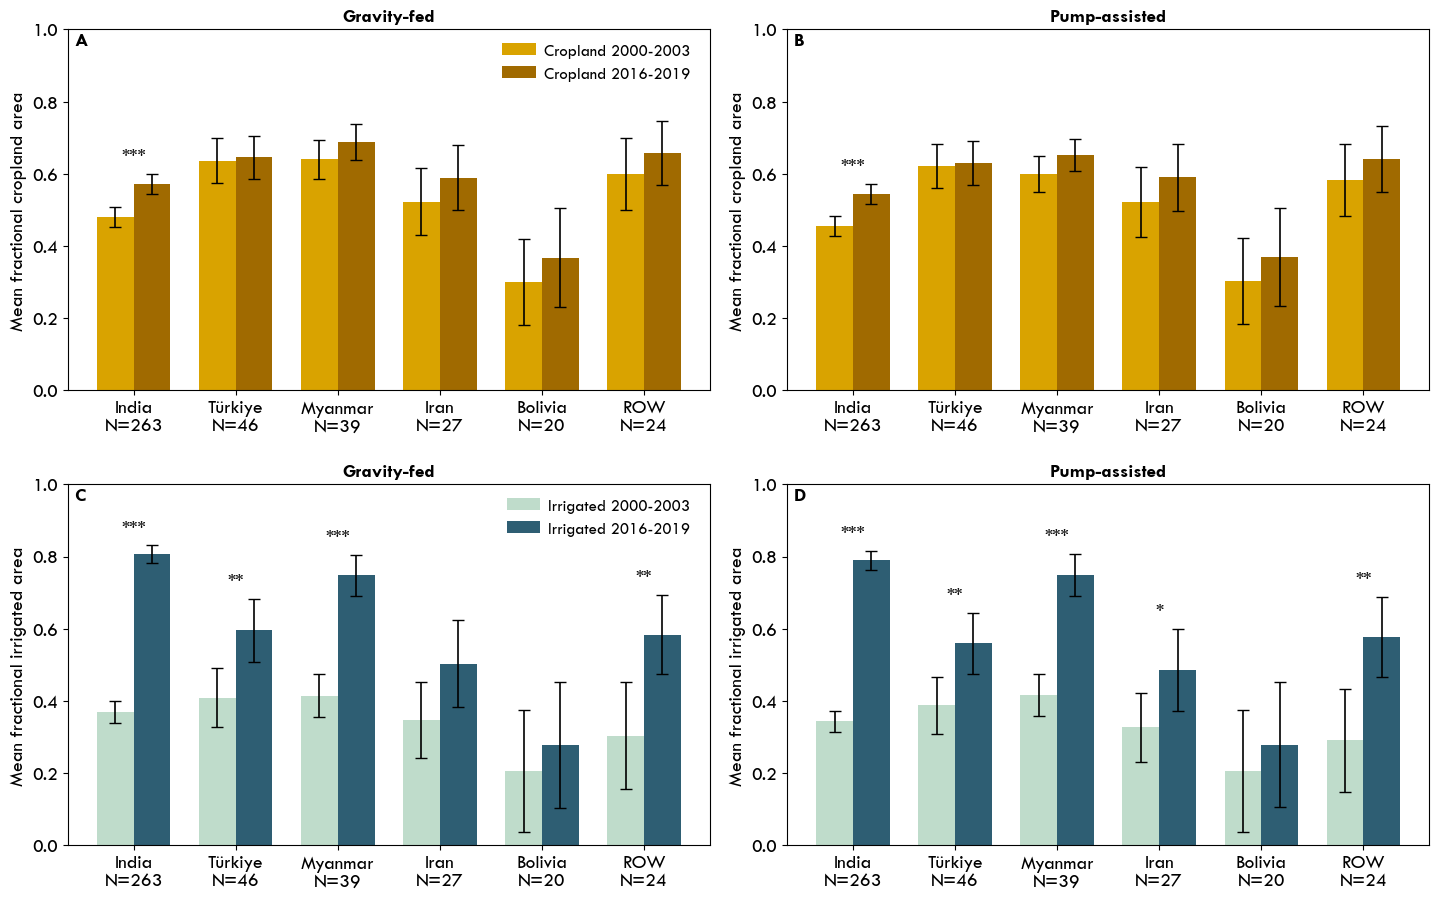

Saved: E:\New folder\Figure3.png


In [ ]:
import os
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from matplotlib.patches import Patch
from scipy import stats
import statsmodels.formula.api as smf

# ============================================================
# USER SETTINGS
# ============================================================
CSV_CA10 = r"D:\My Drive\CA_10\Merged\CA_10.csv"
CSV_CA50 = r"D:\My Drive\CA_50\Merged\CA-50.csv"

CENTER_THRESHOLD = 0.4

PERIOD_A = "2000_2003"
PERIOD_B = "2016_2019"

EXCLUDE_COUNTRIES = set()   
TOP_N = 5
MAKE_ROW = True

ADD_SIGNIFICANCE = True

# OLS-style significance thresholds
#   *    p < 0.05
#   **   p < 0.01
#   ***  p < 0.001
SIG_P1 = 0.05    # *
SIG_P2 = 0.01    # **
SIG_P3 = 0.001   # ***

# --- Saving 
OUTPUT_DIR = r"E:\COmman Area\FIgures"
OUTPUT_STEM = "Figure_3"
DPI = 300

# Colors by metric
CROP_COLORS = {PERIOD_A: "#D9A300", PERIOD_B: "#A06A00"}
IRR_COLORS  = {PERIOD_A: "#BFDCCB", PERIOD_B: "#2E5E73"}
LEGEND_LABELS = {PERIOD_A: "2000-2003", PERIOD_B: "2016-2019"}

TITLE_CA10 = "Gravity-fed"
TITLE_CA50 = "Pump-assisted"

COUNTRY_RENAME = {
    "Turkey": "Türkiye",
}

CROP_LEGEND_LOC = "upper right"
CROP_LEGEND_BBOX = (0.98, 0.98)
IRR_LEGEND_LOC = "upper right"
IRR_LEGEND_BBOX = (0.98, 0.98)

# Font
TARGET_FONT = "Tw Cen MT"
BASE_FONTSIZE = 14
TITLE_FONTSIZE = 14
PANELTAG_FONTSIZE = 14
TICK_FONTSIZE = 14
LEGEND_FONTSIZE = 12

mpl.rcParams.update({
    "font.family": TARGET_FONT,
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": TITLE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
    "legend.fontsize": LEGEND_FONTSIZE,
})


def unique_png_path(output_dir: str, stem: str) -> str:
    os.makedirs(output_dir, exist_ok=True)
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    candidate = os.path.join(output_dir, f"{stem}_{ts}.png")
    if not os.path.exists(candidate):
        return candidate
    k = 2
    while True:
        candidate2 = os.path.join(output_dir, f"{stem}_{ts}_{k}.png")
        if not os.path.exists(candidate2):
            return candidate2
        k += 1


def font_available(name: str) -> bool:
    try:
        fp = FontProperties(family=name)
        path = mpl.font_manager.findfont(fp, fallback_to_default=False)
        return os.path.exists(path)
    except Exception:
        return False


def standardize_country_names(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["Country"] = df["Country"].replace(COUNTRY_RENAME)
    return df


def read_and_filter(csv_path: str, center_thr: float) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    df["Country"] = df["Country"].astype(str).str.strip()
    df["period"] = df["period"].astype(str).str.strip()
    df = standardize_country_names(df)

    df = df[df["period"].isin([PERIOD_A, PERIOD_B])].copy()

    if EXCLUDE_COUNTRIES:
        exclude_countries = {COUNTRY_RENAME.get(c, c) for c in EXCLUDE_COUNTRIES}
        df = df[~df["Country"].isin(exclude_countries)].copy()

    df["threshold"] = pd.to_numeric(df["threshold"], errors="coerce")
    df["frac_cropland"] = pd.to_numeric(df["frac_cropland"], errors="coerce")
    df["frac_irrig_in_cropland"] = pd.to_numeric(df["frac_irrig_in_cropland"], errors="coerce")

    # keep ONLY threshold==0.4 (float-safe)
    df = df[np.isclose(df["threshold"], center_thr)].copy()

    df = df.dropna(subset=["Country", "period", "ca_id", "frac_cropland", "frac_irrig_in_cropland"])
    return df


def add_row_category(df: pd.DataFrame, keep_countries: list[str]) -> pd.DataFrame:
    df = df.copy()
    df["country_plot"] = np.where(df["Country"].isin(keep_countries), df["Country"], "ROW")
    return df


def mean_ci95(x: np.ndarray) -> tuple[float, float]:
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)
    if n == 0:
        return np.nan, np.nan
    m = float(np.mean(x))
    if n == 1:
        return m, 0.0
    sd = float(np.std(x, ddof=1))
    se = sd / np.sqrt(n)
    tcrit = stats.t.ppf(0.975, df=n - 1)
    return m, tcrit * se


def country_period_counts(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.dropna(subset=["Country", "period", "ca_id"])
          .groupby(["Country", "period"])["ca_id"]
          .nunique()
          .reset_index(name="n_ca")
    )


def compute_maxN_for_labels(df: pd.DataFrame) -> dict[str, int]:
    tmp = (
        df.groupby(["country_plot", "period"])["ca_id"]
          .nunique()
          .reset_index(name="n_ca")
    )
    return tmp.groupby("country_plot")["n_ca"].max().astype(int).to_dict()


def summarize(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    rows = []
    for (cplot, period), g in df.groupby(["country_plot", "period"], sort=False):
        m, ci = mean_ci95(g[value_col].to_numpy())
        rows.append({"Country": cplot, "period": period, "mean": m, "ci": ci})

    out = pd.DataFrame(rows)
    out["period"] = pd.Categorical(out["period"], categories=[PERIOD_A, PERIOD_B], ordered=True)
    return out.sort_values(["Country", "period"]).reset_index(drop=True)


def significance_by_country(df: pd.DataFrame, value_col: str) -> dict[str, str]:
    """
    OLS-based significance test for the PERIOD_B indicator within each country_plot.

    For each country (or ROW aggregate), fit:
        value ~ is_period_b

    The p-value on is_period_b tests whether the mean in 2016-2019 differs from
    the mean in 2000-2003 under an OLS model. 
    """
    stars = {}

    for cplot, g in df.groupby("country_plot", sort=False):
        d = g[["period", value_col]].copy()
        d = d.dropna(subset=["period", value_col])
        d = d[d["period"].isin([PERIOD_A, PERIOD_B])].copy()

        if d.empty:
            stars[cplot] = ""
            continue

        n_a = int((d["period"] == PERIOD_A).sum())
        n_b = int((d["period"] == PERIOD_B).sum())
        if n_a < 2 or n_b < 2:
            stars[cplot] = ""
            continue

        d["is_period_b"] = (d["period"] == PERIOD_B).astype(int)

        try:
            model = smf.ols(f"{value_col} ~ is_period_b", data=d).fit()
            p = float(model.pvalues.get("is_period_b", np.nan))
        except Exception:
            stars[cplot] = ""
            continue

        if not np.isfinite(p):
            stars[cplot] = ""
        elif p < SIG_P3:
            stars[cplot] = "***"
        elif p < SIG_P2:
            stars[cplot] = "**"
        elif p < SIG_P1:
            stars[cplot] = "*"
        else:
            stars[cplot] = ""

    return stars


def pull(summary_df: pd.DataFrame, order: list[str], period: str):
    s = summary_df[summary_df["period"] == period].set_index("Country").reindex(order)
    return s["mean"].to_numpy(float), s["ci"].to_numpy(float)


def build_both_datasets(csv_ca10: str, csv_ca50: str):
    df10 = read_and_filter(csv_ca10, CENTER_THRESHOLD)
    df50 = read_and_filter(csv_ca50, CENTER_THRESHOLD)

    max10 = country_period_counts(df10).groupby("Country")["n_ca"].max()
    max50 = country_period_counts(df50).groupby("Country")["n_ca"].max()

    rank_score = (max10.add(max50, fill_value=0)).sort_values(ascending=False)
    top = rank_score.head(TOP_N).index.tolist()

    if MAKE_ROW:
        df10 = add_row_category(df10, keep_countries=top)
        df50 = add_row_category(df50, keep_countries=top)
        order = top + ["ROW"]
    else:
        df10["country_plot"] = df10["Country"]
        df50["country_plot"] = df50["Country"]
        order = top

    maxN10 = compute_maxN_for_labels(df10)
    labels = [f"{c}\nN={maxN10.get(c, 0)}" for c in order]

    summ10_crop = summarize(df10, "frac_cropland")
    summ10_irr  = summarize(df10, "frac_irrig_in_cropland")
    summ50_crop = summarize(df50, "frac_cropland")
    summ50_irr  = summarize(df50, "frac_irrig_in_cropland")

    sig10_crop = significance_by_country(df10, "frac_cropland") if ADD_SIGNIFICANCE else None
    sig10_irr  = significance_by_country(df10, "frac_irrig_in_cropland") if ADD_SIGNIFICANCE else None
    sig50_crop = significance_by_country(df50, "frac_cropland") if ADD_SIGNIFICANCE else None
    sig50_irr  = significance_by_country(df50, "frac_irrig_in_cropland") if ADD_SIGNIFICANCE else None

    return {
        "order": order,
        "labels": labels,
        "ca10": {"crop": summ10_crop, "irr": summ10_irr, "sig_crop": sig10_crop, "sig_irr": sig10_irr},
        "ca50": {"crop": summ50_crop, "irr": summ50_irr, "sig_crop": sig50_crop, "sig_irr": sig50_irr},
    }


# ============================================================
# PLOTTING: CA10 vs CA50 
# ============================================================
def plot_2x2_side_by_side(
    order: list[str],
    labels: list[str],
    ca10_crop: pd.DataFrame,
    ca50_crop: pd.DataFrame,
    ca10_irr: pd.DataFrame,
    ca50_irr: pd.DataFrame,
    sig10_crop=None,
    sig50_crop=None,
    sig10_irr=None,
    sig50_irr=None
):
    width = 0.36

    fig, axes = plt.subplots(2, 2, figsize=(14.8, 9.6))
    fig.subplots_adjust(left=0.06, right=0.98, bottom=0.07, top=0.92, wspace=0.12, hspace=0.26)

    crop_handles = [
        Patch(facecolor=CROP_COLORS[PERIOD_A], edgecolor="none", label=f"Cropland {LEGEND_LABELS[PERIOD_A]}"),
        Patch(facecolor=CROP_COLORS[PERIOD_B], edgecolor="none", label=f"Cropland {LEGEND_LABELS[PERIOD_B]}"),
    ]
    irr_handles = [
        Patch(facecolor=IRR_COLORS[PERIOD_A], edgecolor="none", label=f"Irrigated {LEGEND_LABELS[PERIOD_A]}"),
        Patch(facecolor=IRR_COLORS[PERIOD_B], edgecolor="none", label=f"Irrigated {LEGEND_LABELS[PERIOD_B]}"),
    ]

    def draw_panel(ax, summ, colors, ylabel, title, panel_tag, sig=None, legend_handles=None, legend_loc=None, legend_bbox=None):
        x = np.arange(len(order))
        y_a, ci_a = pull(summ, order, PERIOD_A)
        y_b, ci_b = pull(summ, order, PERIOD_B)

        ax.bar(x - width / 2, y_a, width=width, color=colors[PERIOD_A], edgecolor="none")
        ax.errorbar(x - width / 2, y_a, yerr=ci_a, fmt="none", ecolor="black", elinewidth=1.2, capsize=4)

        ax.bar(x + width / 2, y_b, width=width, color=colors[PERIOD_B], edgecolor="none")
        ax.errorbar(x + width / 2, y_b, yerr=ci_b, fmt="none", ecolor="black", elinewidth=1.2, capsize=4)

        ax.set_ylabel(ylabel)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=0)
        ax.set_ylim(0, 1.0)
        ax.set_title(title, fontsize=TITLE_FONTSIZE, fontweight="bold", pad=6)

        ax.text(
            0.01,
            0.99,
            panel_tag,
            transform=ax.transAxes,
            fontsize=PANELTAG_FONTSIZE,
            fontweight="bold",
            ha="left",
            va="top",
        )

        if sig:
            for i, c in enumerate(order):
                s = sig.get(c, "")
                if s:
                    topv = np.nanmax([y_a[i] + ci_a[i], y_b[i] + ci_b[i]])
                    if np.isfinite(topv):
                        ax.text(
                            i,
                            min(topv + 0.03, 0.98),
                            s,
                            ha="center",
                            va="bottom",
                            fontsize=PANELTAG_FONTSIZE,
                            fontweight="bold",
                            color="black",
                        )

        if legend_handles is not None:
            ax.legend(
                handles=legend_handles,
                frameon=False,
                ncol=1,
                loc=legend_loc,
                bbox_to_anchor=legend_bbox,
                borderaxespad=0.0,
                handletextpad=0.5,
                columnspacing=0.8,
            )

        ax.spines["top"].set_visible(True)
        ax.spines["right"].set_visible(True)

    draw_panel(
        axes[0, 0],
        ca10_crop,
        CROP_COLORS,
        ylabel="Mean fractional cropland area",
        title=TITLE_CA10,
        panel_tag="A",
        sig=sig10_crop,
        legend_handles=crop_handles,
        legend_loc=CROP_LEGEND_LOC,
        legend_bbox=CROP_LEGEND_BBOX,
    )

    draw_panel(
        axes[0, 1],
        ca50_crop,
        CROP_COLORS,
        ylabel="Mean fractional cropland area",
        title=TITLE_CA50,
        panel_tag="B",
        sig=sig50_crop,
    )

    draw_panel(
        axes[1, 0],
        ca10_irr,
        IRR_COLORS,
        ylabel="Mean fractional irrigated area",
        title=TITLE_CA10,
        panel_tag="C",
        sig=sig10_irr,
        legend_handles=irr_handles,
        legend_loc=IRR_LEGEND_LOC,
        legend_bbox=IRR_LEGEND_BBOX,
    )

    draw_panel(
        axes[1, 1],
        ca50_irr,
        IRR_COLORS,
        ylabel="Mean fractional irrigated area",
        title=TITLE_CA50,
        panel_tag="D",
        sig=sig50_irr,
    )

    return fig


# ============================================================
# MAIN
# ============================================================
def main():
    if not font_available(TARGET_FONT):
        print(f"WARNING: Font '{TARGET_FONT}' not found. Install it to match the paper exactly.")
        print("If you're on Windows, install 'Tw Cen MT' system-wide, then restart your Python session.")

    pack = build_both_datasets(CSV_CA10, CSV_CA50)

    fig = plot_2x2_side_by_side(
        order=pack["order"],
        labels=pack["labels"],
        ca10_crop=pack["ca10"]["crop"],
        ca50_crop=pack["ca50"]["crop"],
        ca10_irr=pack["ca10"]["irr"],
        ca50_irr=pack["ca50"]["irr"],
        sig10_crop=pack["ca10"]["sig_crop"],
        sig50_crop=pack["ca50"]["sig_crop"],
        sig10_irr=pack["ca10"]["sig_irr"],
        sig50_irr=pack["ca50"]["sig_irr"],
    )

    out_path = r"E:\New folder\Figure3.png"
    fig.savefig(out_path, dpi=DPI, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")


if __name__ == "__main__":
    main()


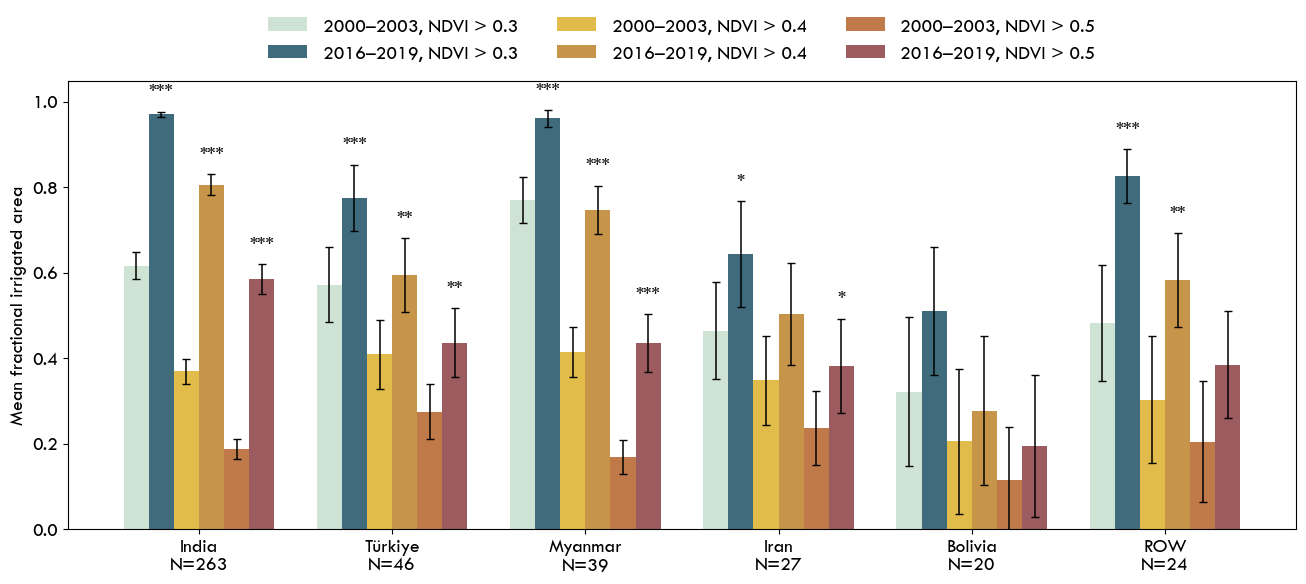

Saved: E:\New folder\Figure S1.png


In [6]:
import os
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from scipy import stats
import statsmodels.formula.api as smf

CSV_PATH = r"D:\My Drive\CA_10\Merged\CA_10.csv"

PERIOD_A = "2000_2003"
PERIOD_B = "2016_2019"
PERIODS = [PERIOD_A, PERIOD_B]

THRESHOLDS = [0.3, 0.4, 0.5]

RANK_THRESHOLD = 0.4

EXCLUDE_COUNTRIES = set()
TOP_N = 5
MAKE_ROW = True

# OLS-style significance thresholds 
#   *    p < 0.05
#   **   p < 0.01
#   ***  p < 0.001
ADD_SIGNIFICANCE = True
SIG_P1 = 0.05    # *
SIG_P2 = 0.01    # **
SIG_P3 = 0.001   # ***

# --- Saving
OUTPUT_DIR = r"E:\Command Area\Figures"
OUTPUT_STEM = "Irrigation_MultiThreshold_CA10"
DPI = 300

TARGET_FONT = "Tw Cen MT"
BASE_FONTSIZE = 14
TITLE_FONTSIZE = 14
PANELTAG_FONTSIZE = 14
TICK_FONTSIZE = 14
LEGEND_FONTSIZE = 14

mpl.rcParams.update({
    "font.family": TARGET_FONT,
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": TITLE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
    "legend.fontsize": LEGEND_FONTSIZE,
})

COLORS = {
    (PERIOD_A, 0.3): "#CFE3D5",
    (PERIOD_A, 0.4): "#E2BC4A",
    (PERIOD_A, 0.5): "#C07A4A",
    (PERIOD_B, 0.3): "#3F6B7D",
    (PERIOD_B, 0.4): "#C7954A",
    (PERIOD_B, 0.5): "#9B5B5F",
}

LEGEND_LABELS = {
    (PERIOD_A, 0.3): "2000–2003, NDVI > 0.3",
    (PERIOD_A, 0.4): "2000–2003, NDVI > 0.4",
    (PERIOD_A, 0.5): "2000–2003, NDVI > 0.5",
    (PERIOD_B, 0.3): "2016–2019, NDVI > 0.3",
    (PERIOD_B, 0.4): "2016–2019, NDVI > 0.4",
    (PERIOD_B, 0.5): "2016–2019, NDVI > 0.5",
}


def unique_png_path(output_dir: str, stem: str) -> str:
    os.makedirs(output_dir, exist_ok=True)
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    candidate = os.path.join(output_dir, f"{stem}_{ts}.png")
    if not os.path.exists(candidate):
        return candidate
    k = 2
    while True:
        candidate2 = os.path.join(output_dir, f"{stem}_{ts}_{k}.png")
        if not os.path.exists(candidate2):
            return candidate2
        k += 1


def font_available(name: str) -> bool:
    try:
        fp = FontProperties(family=name)
        path = mpl.font_manager.findfont(fp, fallback_to_default=False)
        return os.path.exists(path)
    except Exception:
        return False


def read_and_filter(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    df["Country"] = df["Country"].astype(str).str.strip()
    df["Country"] = df["Country"].replace({"Turkey": "Türkiye"})
    df["period"] = df["period"].astype(str).str.strip()

    # keep only the periods we plot
    df = df[df["period"].isin(PERIODS)].copy()

    if EXCLUDE_COUNTRIES:
        df = df[~df["Country"].isin(EXCLUDE_COUNTRIES)].copy()

    df["threshold"] = pd.to_numeric(df["threshold"], errors="coerce")
    df["frac_irrig_in_cropland"] = pd.to_numeric(df["frac_irrig_in_cropland"], errors="coerce")

    # keep only thresholds we plot
    df = df[df["threshold"].apply(lambda v: np.any(np.isclose(v, THRESHOLDS)))].copy()

    df = df.dropna(subset=["Country", "period", "ca_id", "threshold", "frac_irrig_in_cropland"])
    return df


def add_row_category(df: pd.DataFrame, keep_countries: list[str]) -> pd.DataFrame:
    df = df.copy()
    df["country_plot"] = np.where(df["Country"].isin(keep_countries), df["Country"], "ROW")
    return df


def mean_ci95(x: np.ndarray) -> tuple[float, float]:
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)
    if n == 0:
        return np.nan, np.nan
    m = float(np.mean(x))
    if n == 1:
        return m, 0.0
    sd = float(np.std(x, ddof=1))
    se = sd / np.sqrt(n)
    tcrit = stats.t.ppf(0.975, df=n - 1)
    return m, tcrit * se


def country_period_counts_for_threshold(df: pd.DataFrame, thr: float) -> pd.DataFrame:
    d = df[np.isclose(df["threshold"].astype(float), thr)].copy()
    return (
        d.groupby(["Country", "period"])["ca_id"]
         .nunique()
         .reset_index(name="n_ca")
    )


def top_countries_by_max_ca_count(df: pd.DataFrame, top_n: int, thr_for_counts: float) -> list[str]:
    counts = country_period_counts_for_threshold(df, thr_for_counts)
    max_counts = counts.groupby("Country")["n_ca"].max().sort_values(ascending=False)
    return max_counts.head(top_n).index.tolist()


def compute_maxN_for_labels(df: pd.DataFrame, thr_for_counts: float) -> dict[str, int]:
    """
    After country_plot exists:
      N(label) = max over periods of unique ca_id count at threshold==thr_for_counts.
    """
    d = df[np.isclose(df["threshold"].astype(float), thr_for_counts)].copy()
    tmp = (
        d.groupby(["country_plot", "period"])["ca_id"]
         .nunique()
         .reset_index(name="n_ca")
    )
    return tmp.groupby("country_plot")["n_ca"].max().fillna(0).astype(int).to_dict()


# ------------------------------------------------------------
# Summaries per (country_plot, period, threshold)
# ------------------------------------------------------------
def summarize(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    rows = []
    for (country, period, thr), g in df.groupby(["country_plot", "period", "threshold"], sort=False):
        m, ci = mean_ci95(g[value_col].to_numpy())
        rows.append({
            "Country": country,
            "period": period,
            "threshold": float(thr),
            "mean": m,
            "ci": ci,
        })
    out = pd.DataFrame(rows)
    out["period"] = pd.Categorical(out["period"], categories=PERIODS, ordered=True)
    out["threshold"] = pd.Categorical(out["threshold"], categories=THRESHOLDS, ordered=True)
    return out.sort_values(["Country", "period", "threshold"]).reset_index(drop=True)


def sig_stars_by_country_threshold(df: pd.DataFrame, value_col: str) -> dict[tuple[str, float], str]:
    """
    OLS-based significance test between periods WITHIN each (country_plot, threshold).

    For each (country_plot, threshold), fit:
        value ~ is_period_b

    The p-value on is_period_b tests whether the mean in 2016-2019 differs from
    the mean in 2000-2003 under an OLS model.
    """
    stars = {}

    for (country, thr), g in df.groupby(["country_plot", "threshold"], sort=False):
        d = g[["period", value_col]].copy()
        d = d.dropna(subset=["period", value_col])
        d = d[d["period"].isin(PERIODS)].copy()

        n_a = int((d["period"] == PERIOD_A).sum())
        n_b = int((d["period"] == PERIOD_B).sum())
        if n_a < 2 or n_b < 2:
            stars[(country, float(thr))] = ""
            continue

        d["is_period_b"] = (d["period"] == PERIOD_B).astype(int)

        try:
            model = smf.ols(f"{value_col} ~ is_period_b", data=d).fit()
            p = float(model.pvalues.get("is_period_b", np.nan))
        except Exception:
            stars[(country, float(thr))] = ""
            continue

        if not np.isfinite(p):
            stars[(country, float(thr))] = ""
        elif p < SIG_P3:
            stars[(country, float(thr))] = "***"
        elif p < SIG_P2:
            stars[(country, float(thr))] = "**"
        elif p < SIG_P1:
            stars[(country, float(thr))] = "*"
        else:
            stars[(country, float(thr))] = ""

    return stars


# ============================================================
# PLOTTING (SINGLE PANEL, 6 BARS PER COUNTRY)
# ============================================================
def plot_irrigation_multithreshold(
    summary: pd.DataFrame,
    order: list[str],
    xtick_labels: list[str],
    stars: dict[tuple[str, float], str] | None = None
):
    x = np.arange(len(order))

    combos = [
        (PERIOD_A, 0.3), (PERIOD_B, 0.3),
        (PERIOD_A, 0.4), (PERIOD_B, 0.4),
        (PERIOD_A, 0.5), (PERIOD_B, 0.5),
    ]

    n_bars = len(combos)
    group_width = 0.78
    bar_w = group_width / n_bars
    offsets = (np.arange(n_bars) - (n_bars - 1) / 2) * bar_w

    fig, ax = plt.subplots(1, 1, figsize=(13.5, 6.8))
    fig.subplots_adjust(left=0.08, right=0.99, bottom=0.18, top=0.84)

    for j, (period, thr) in enumerate(combos):
        s = summary[
            (summary["period"] == period) &
            (summary["threshold"].astype(float) == float(thr))
        ].set_index("Country").reindex(order)

        y = s["mean"].to_numpy(dtype=float)
        ci = s["ci"].to_numpy(dtype=float)

        ax.bar(
            x + offsets[j], y, width=bar_w,
            color=COLORS[(period, thr)],
            edgecolor="none",
            label=LEGEND_LABELS[(period, thr)]
        )
        ax.errorbar(
            x + offsets[j], y, yerr=ci,
            fmt="none", ecolor="black", elinewidth=1.1, capsize=3
        )

    # significance stars
    if stars:
        for i, country in enumerate(order):
            for thr in THRESHOLDS:
                sstar = stars.get((country, float(thr)), "")
                if not sstar:
                    continue

                j_2016 = combos.index((PERIOD_B, float(thr)))

                s2016 = summary[
                    (summary["Country"] == country) &
                    (summary["period"] == PERIOD_B) &
                    (summary["threshold"].astype(float) == float(thr))
                ]
                s2000 = summary[
                    (summary["Country"] == country) &
                    (summary["period"] == PERIOD_A) &
                    (summary["threshold"].astype(float) == float(thr))
                ]
                if s2016.empty or s2000.empty:
                    continue

                y2016 = float(s2016["mean"].iloc[0])
                ci2016 = float(s2016["ci"].iloc[0])
                y2000 = float(s2000["mean"].iloc[0])
                ci2000 = float(s2000["ci"].iloc[0])

                top = max(y2016 + ci2016, y2000 + ci2000)
                if np.isfinite(top):
                    ax.text(
                        x[i] + offsets[j_2016], min(top + 0.03, 1.03), sstar,
                        ha="center", va="bottom",
                        fontsize=PANELTAG_FONTSIZE, fontweight="bold", color="black"
                    )

    ax.set_ylabel("Mean fractional irrigated area")
    ax.set_xticks(x)
    ax.set_xticklabels(xtick_labels, rotation=0)
    ax.set_ylim(0, 1.05)

    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.18), ncol=3)

    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)

    return fig


# ============================================================
# MAIN
# ============================================================
def main():
    if not font_available(TARGET_FONT):
        print(f"WARNING: Font '{TARGET_FONT}' not found. Install it to match the paper exactly.")
        print("If you're on Windows, install 'Tw Cen MT' system-wide, then restart your Python session.")

    df = read_and_filter(CSV_PATH)

    
    top = top_countries_by_max_ca_count(df, TOP_N, thr_for_counts=RANK_THRESHOLD)

    if MAKE_ROW:
        df = add_row_category(df, keep_countries=top)
        order = top + ["ROW"]
    else:
        df["country_plot"] = df["Country"]
        order = top

    
    maxN = compute_maxN_for_labels(df, thr_for_counts=RANK_THRESHOLD)
    xtick_labels = [f"{c}\nN={maxN.get(c, 0)}" for c in order]

    # summarize (95% CI) per (country_plot, period, threshold)
    summ = summarize(df, "frac_irrig_in_cropland")

    # stars per (country_plot, threshold) from OLS
    stars = sig_stars_by_country_threshold(df, "frac_irrig_in_cropland") if ADD_SIGNIFICANCE else None

    fig = plot_irrigation_multithreshold(summ, order=order, xtick_labels=xtick_labels, stars=stars)

    out_path = r"E:\New folder\Figure S1.png"
    fig.savefig(out_path, dpi=DPI, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")


if __name__ == "__main__":
    main()


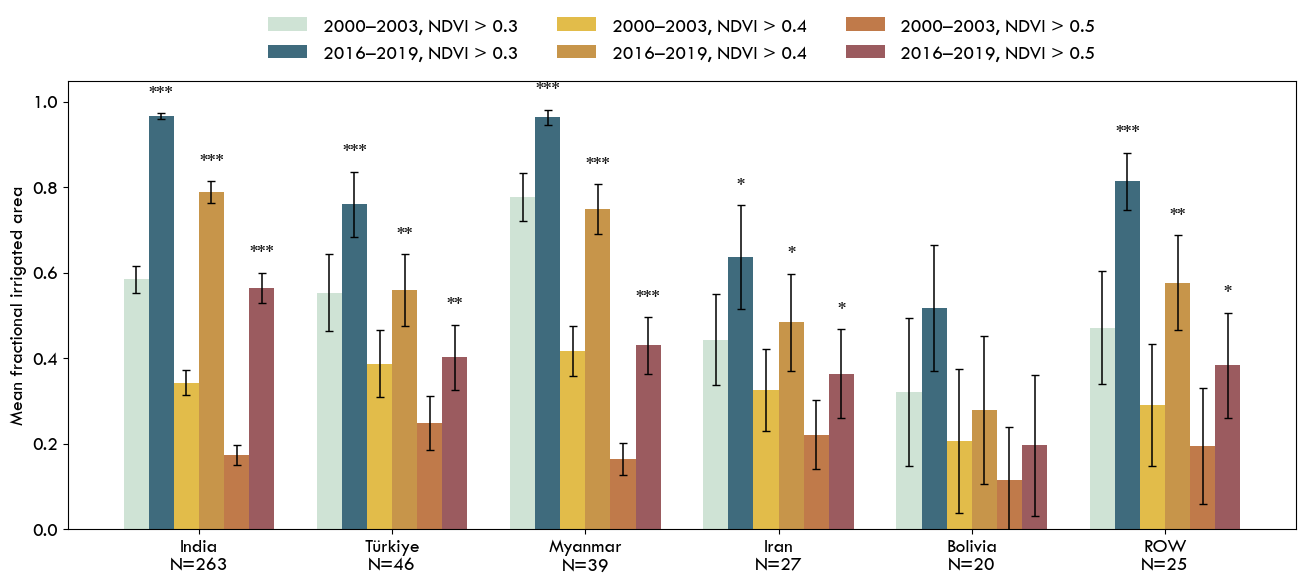

Saved: E:\New folder\Figure S2.png


In [7]:
import os
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from scipy import stats
import statsmodels.formula.api as smf

CSV_PATH = r"D:\My Drive\CA_50\Merged\CA-50.csv"

PERIOD_A = "2000_2003"
PERIOD_B = "2016_2019"
PERIODS = [PERIOD_A, PERIOD_B]

THRESHOLDS = [0.3, 0.4, 0.5]

RANK_THRESHOLD = 0.4

EXCLUDE_COUNTRIES = set()
TOP_N = 5
MAKE_ROW = True

# OLS-style significance thresholds 
#   *    p < 0.05
#   **   p < 0.01
#   ***  p < 0.001
ADD_SIGNIFICANCE = True
SIG_P1 = 0.05    # *
SIG_P2 = 0.01    # **
SIG_P3 = 0.001   # ***

# --- Saving
OUTPUT_DIR = r"E:\Command Area\Figures"
OUTPUT_STEM = "Irrigation_MultiThreshold_CA10"
DPI = 300

TARGET_FONT = "Tw Cen MT"
BASE_FONTSIZE = 14
TITLE_FONTSIZE = 14
PANELTAG_FONTSIZE = 14
TICK_FONTSIZE = 14
LEGEND_FONTSIZE = 14

mpl.rcParams.update({
    "font.family": TARGET_FONT,
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": TITLE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
    "legend.fontsize": LEGEND_FONTSIZE,
})

COLORS = {
    (PERIOD_A, 0.3): "#CFE3D5",
    (PERIOD_A, 0.4): "#E2BC4A",
    (PERIOD_A, 0.5): "#C07A4A",
    (PERIOD_B, 0.3): "#3F6B7D",
    (PERIOD_B, 0.4): "#C7954A",
    (PERIOD_B, 0.5): "#9B5B5F",
}

LEGEND_LABELS = {
    (PERIOD_A, 0.3): "2000–2003, NDVI > 0.3",
    (PERIOD_A, 0.4): "2000–2003, NDVI > 0.4",
    (PERIOD_A, 0.5): "2000–2003, NDVI > 0.5",
    (PERIOD_B, 0.3): "2016–2019, NDVI > 0.3",
    (PERIOD_B, 0.4): "2016–2019, NDVI > 0.4",
    (PERIOD_B, 0.5): "2016–2019, NDVI > 0.5",
}


def unique_png_path(output_dir: str, stem: str) -> str:
    os.makedirs(output_dir, exist_ok=True)
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    candidate = os.path.join(output_dir, f"{stem}_{ts}.png")
    if not os.path.exists(candidate):
        return candidate
    k = 2
    while True:
        candidate2 = os.path.join(output_dir, f"{stem}_{ts}_{k}.png")
        if not os.path.exists(candidate2):
            return candidate2
        k += 1


def font_available(name: str) -> bool:
    try:
        fp = FontProperties(family=name)
        path = mpl.font_manager.findfont(fp, fallback_to_default=False)
        return os.path.exists(path)
    except Exception:
        return False


def read_and_filter(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    df["Country"] = df["Country"].astype(str).str.strip()
    df["Country"] = df["Country"].replace({"Turkey": "Türkiye"})
    df["period"] = df["period"].astype(str).str.strip()

    # keep only the periods we plot
    df = df[df["period"].isin(PERIODS)].copy()

    if EXCLUDE_COUNTRIES:
        df = df[~df["Country"].isin(EXCLUDE_COUNTRIES)].copy()

    df["threshold"] = pd.to_numeric(df["threshold"], errors="coerce")
    df["frac_irrig_in_cropland"] = pd.to_numeric(df["frac_irrig_in_cropland"], errors="coerce")

    # keep only thresholds we plot
    df = df[df["threshold"].apply(lambda v: np.any(np.isclose(v, THRESHOLDS)))].copy()

    df = df.dropna(subset=["Country", "period", "ca_id", "threshold", "frac_irrig_in_cropland"])
    return df


def add_row_category(df: pd.DataFrame, keep_countries: list[str]) -> pd.DataFrame:
    df = df.copy()
    df["country_plot"] = np.where(df["Country"].isin(keep_countries), df["Country"], "ROW")
    return df


def mean_ci95(x: np.ndarray) -> tuple[float, float]:
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)
    if n == 0:
        return np.nan, np.nan
    m = float(np.mean(x))
    if n == 1:
        return m, 0.0
    sd = float(np.std(x, ddof=1))
    se = sd / np.sqrt(n)
    tcrit = stats.t.ppf(0.975, df=n - 1)
    return m, tcrit * se


def country_period_counts_for_threshold(df: pd.DataFrame, thr: float) -> pd.DataFrame:
    d = df[np.isclose(df["threshold"].astype(float), thr)].copy()
    return (
        d.groupby(["Country", "period"])["ca_id"]
         .nunique()
         .reset_index(name="n_ca")
    )


def top_countries_by_max_ca_count(df: pd.DataFrame, top_n: int, thr_for_counts: float) -> list[str]:
    counts = country_period_counts_for_threshold(df, thr_for_counts)
    max_counts = counts.groupby("Country")["n_ca"].max().sort_values(ascending=False)
    return max_counts.head(top_n).index.tolist()


def compute_maxN_for_labels(df: pd.DataFrame, thr_for_counts: float) -> dict[str, int]:
    """
    After country_plot exists:
      N(label) = max over periods of unique ca_id count at threshold==thr_for_counts.
    """
    d = df[np.isclose(df["threshold"].astype(float), thr_for_counts)].copy()
    tmp = (
        d.groupby(["country_plot", "period"])["ca_id"]
         .nunique()
         .reset_index(name="n_ca")
    )
    return tmp.groupby("country_plot")["n_ca"].max().fillna(0).astype(int).to_dict()


# ------------------------------------------------------------
# Summaries per (country_plot, period, threshold)
# ------------------------------------------------------------
def summarize(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    rows = []
    for (country, period, thr), g in df.groupby(["country_plot", "period", "threshold"], sort=False):
        m, ci = mean_ci95(g[value_col].to_numpy())
        rows.append({
            "Country": country,
            "period": period,
            "threshold": float(thr),
            "mean": m,
            "ci": ci,
        })
    out = pd.DataFrame(rows)
    out["period"] = pd.Categorical(out["period"], categories=PERIODS, ordered=True)
    out["threshold"] = pd.Categorical(out["threshold"], categories=THRESHOLDS, ordered=True)
    return out.sort_values(["Country", "period", "threshold"]).reset_index(drop=True)


def sig_stars_by_country_threshold(df: pd.DataFrame, value_col: str) -> dict[tuple[str, float], str]:
    """
    OLS-based significance test between periods WITHIN each (country_plot, threshold).

    For each (country_plot, threshold), fit:
        value ~ is_period_b

    The p-value on is_period_b tests whether the mean in 2016-2019 differs from
    the mean in 2000-2003 under an OLS model.
    """
    stars = {}

    for (country, thr), g in df.groupby(["country_plot", "threshold"], sort=False):
        d = g[["period", value_col]].copy()
        d = d.dropna(subset=["period", value_col])
        d = d[d["period"].isin(PERIODS)].copy()

        n_a = int((d["period"] == PERIOD_A).sum())
        n_b = int((d["period"] == PERIOD_B).sum())
        if n_a < 2 or n_b < 2:
            stars[(country, float(thr))] = ""
            continue

        d["is_period_b"] = (d["period"] == PERIOD_B).astype(int)

        try:
            model = smf.ols(f"{value_col} ~ is_period_b", data=d).fit()
            p = float(model.pvalues.get("is_period_b", np.nan))
        except Exception:
            stars[(country, float(thr))] = ""
            continue

        if not np.isfinite(p):
            stars[(country, float(thr))] = ""
        elif p < SIG_P3:
            stars[(country, float(thr))] = "***"
        elif p < SIG_P2:
            stars[(country, float(thr))] = "**"
        elif p < SIG_P1:
            stars[(country, float(thr))] = "*"
        else:
            stars[(country, float(thr))] = ""

    return stars


# ============================================================
# PLOTTING (SINGLE PANEL, 6 BARS PER COUNTRY)
# ============================================================
def plot_irrigation_multithreshold(
    summary: pd.DataFrame,
    order: list[str],
    xtick_labels: list[str],
    stars: dict[tuple[str, float], str] | None = None
):
    x = np.arange(len(order))

    combos = [
        (PERIOD_A, 0.3), (PERIOD_B, 0.3),
        (PERIOD_A, 0.4), (PERIOD_B, 0.4),
        (PERIOD_A, 0.5), (PERIOD_B, 0.5),
    ]

    n_bars = len(combos)
    group_width = 0.78
    bar_w = group_width / n_bars
    offsets = (np.arange(n_bars) - (n_bars - 1) / 2) * bar_w

    fig, ax = plt.subplots(1, 1, figsize=(13.5, 6.8))
    fig.subplots_adjust(left=0.08, right=0.99, bottom=0.18, top=0.84)

    for j, (period, thr) in enumerate(combos):
        s = summary[
            (summary["period"] == period) &
            (summary["threshold"].astype(float) == float(thr))
        ].set_index("Country").reindex(order)

        y = s["mean"].to_numpy(dtype=float)
        ci = s["ci"].to_numpy(dtype=float)

        ax.bar(
            x + offsets[j], y, width=bar_w,
            color=COLORS[(period, thr)],
            edgecolor="none",
            label=LEGEND_LABELS[(period, thr)]
        )
        ax.errorbar(
            x + offsets[j], y, yerr=ci,
            fmt="none", ecolor="black", elinewidth=1.1, capsize=3
        )

    # significance stars
    if stars:
        for i, country in enumerate(order):
            for thr in THRESHOLDS:
                sstar = stars.get((country, float(thr)), "")
                if not sstar:
                    continue

                j_2016 = combos.index((PERIOD_B, float(thr)))

                s2016 = summary[
                    (summary["Country"] == country) &
                    (summary["period"] == PERIOD_B) &
                    (summary["threshold"].astype(float) == float(thr))
                ]
                s2000 = summary[
                    (summary["Country"] == country) &
                    (summary["period"] == PERIOD_A) &
                    (summary["threshold"].astype(float) == float(thr))
                ]
                if s2016.empty or s2000.empty:
                    continue

                y2016 = float(s2016["mean"].iloc[0])
                ci2016 = float(s2016["ci"].iloc[0])
                y2000 = float(s2000["mean"].iloc[0])
                ci2000 = float(s2000["ci"].iloc[0])

                top = max(y2016 + ci2016, y2000 + ci2000)
                if np.isfinite(top):
                    ax.text(
                        x[i] + offsets[j_2016], min(top + 0.03, 1.03), sstar,
                        ha="center", va="bottom",
                        fontsize=PANELTAG_FONTSIZE, fontweight="bold", color="black"
                    )

    ax.set_ylabel("Mean fractional irrigated area")
    ax.set_xticks(x)
    ax.set_xticklabels(xtick_labels, rotation=0)
    ax.set_ylim(0, 1.05)

    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.18), ncol=3)

    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)

    return fig


# ============================================================
# MAIN
# ============================================================
def main():
    if not font_available(TARGET_FONT):
        print(f"WARNING: Font '{TARGET_FONT}' not found. Install it to match the paper exactly.")
        print("If you're on Windows, install 'Tw Cen MT' system-wide, then restart your Python session.")

    df = read_and_filter(CSV_PATH)

    
    top = top_countries_by_max_ca_count(df, TOP_N, thr_for_counts=RANK_THRESHOLD)

    if MAKE_ROW:
        df = add_row_category(df, keep_countries=top)
        order = top + ["ROW"]
    else:
        df["country_plot"] = df["Country"]
        order = top

    
    maxN = compute_maxN_for_labels(df, thr_for_counts=RANK_THRESHOLD)
    xtick_labels = [f"{c}\nN={maxN.get(c, 0)}" for c in order]

    # summarize (95% CI) per (country_plot, period, threshold)
    summ = summarize(df, "frac_irrig_in_cropland")

    # stars per (country_plot, threshold) from OLS
    stars = sig_stars_by_country_threshold(df, "frac_irrig_in_cropland") if ADD_SIGNIFICANCE else None

    fig = plot_irrigation_multithreshold(summ, order=order, xtick_labels=xtick_labels, stars=stars)

    out_path = r"E:\New folder\Figure S2.png"
    fig.savefig(out_path, dpi=DPI, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")


if __name__ == "__main__":
    main()
